 # 1. Perform EDA (Exploratory Data Analysis) on a dataset.
# 2. Create a regression model to predict sales

In [27]:
df = pd.read_excel('task 4/Sample data (1).xlsx')
df


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.00,529550.00,393380.0,136170.00,2014-12-01,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.00,352100.00,261560.0,90540.00,2014-06-01,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.00,603750.00,448500.0,155250.00,2013-11-01,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.00,529550.00,393380.0,136170.00,2014-12-01,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.00,352100.00,261560.0,90540.00,2014-06-01,6,June,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Midmarket,Canada,Paseo,High,1614.0,10,15,24210.0,3631.50,20578.50,16140.0,4438.50,2014-04-01,4,April,2014
696,Midmarket,Canada,Paseo,High,2559.0,10,15,38385.0,5757.75,32627.25,25590.0,7037.25,2014-08-01,8,August,2014
697,Enterprise,Germany,Paseo,High,1085.0,10,125,135625.0,20343.75,115281.25,130200.0,-14918.75,2014-10-01,10,October,2014
698,Midmarket,Germany,Paseo,High,1175.0,10,15,17625.0,2643.75,14981.25,11750.0,3231.25,2014-10-01,10,October,2014


In [28]:
df.to_csv('task 4/Sample_data_1.csv', index=False)
print("Conversion successful! CSV saved.")

df = pd.read_csv('task 4/Sample_data_1.csv')

Conversion successful! CSV saved.


# Exploratory Data Analysis (EDA)

In [29]:
# Display the first 5 rows
print("--- First 5 Rows ---")
print(df.head())

# Check data types, missing values, and shape
print("\n--- Data Info ---")
print(df.info())

# Summary statistics for numerical columns
print("\n--- Summary Statistics ---")
print(df.describe())

# Check for missing values explicitly
print("\n--- Missing Values Counter ---")
print(df.isnull().sum())

--- First 5 Rows ---
      Segment  Country    Product Discount Band  Units Sold  \
0  Government  Germany  Carretera           NaN      1513.0   
1  Government  Germany      Paseo           NaN      1006.0   
2  Government   Canada      Paseo           NaN      1725.0   
3  Government  Germany      Paseo           NaN      1513.0   
4  Government  Germany       Velo           NaN      1006.0   

   Manufacturing Price  Sale Price  Gross Sales  Discounts     Sales  \
0                    3         350     529550.0        0.0  529550.0   
1                   10         350     352100.0        0.0  352100.0   
2                   10         350     603750.0        0.0  603750.0   
3                   10         350     529550.0        0.0  529550.0   
4                  120         350     352100.0        0.0  352100.0   

       COGS    Profit        Date  Month Number Month Name  Year  
0  393380.0  136170.0  2014-12-01            12   December  2014  
1  261560.0   90540.0  2014-06-01

## Visualizations

In [32]:
print(df.columns.tolist())

['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


In [37]:
clean_col=df.columns = df.columns.str.strip()
clean_col

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='object')

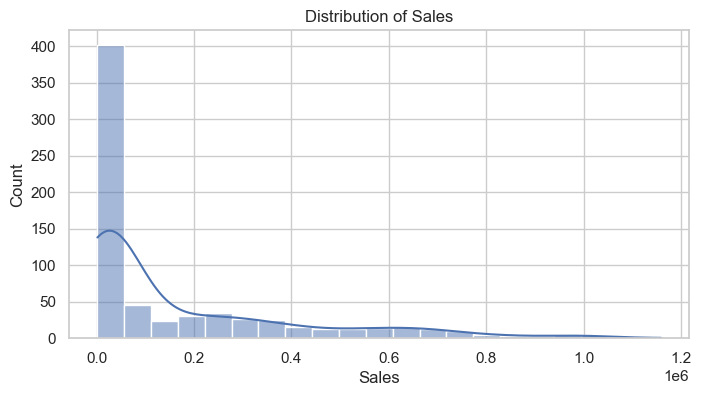

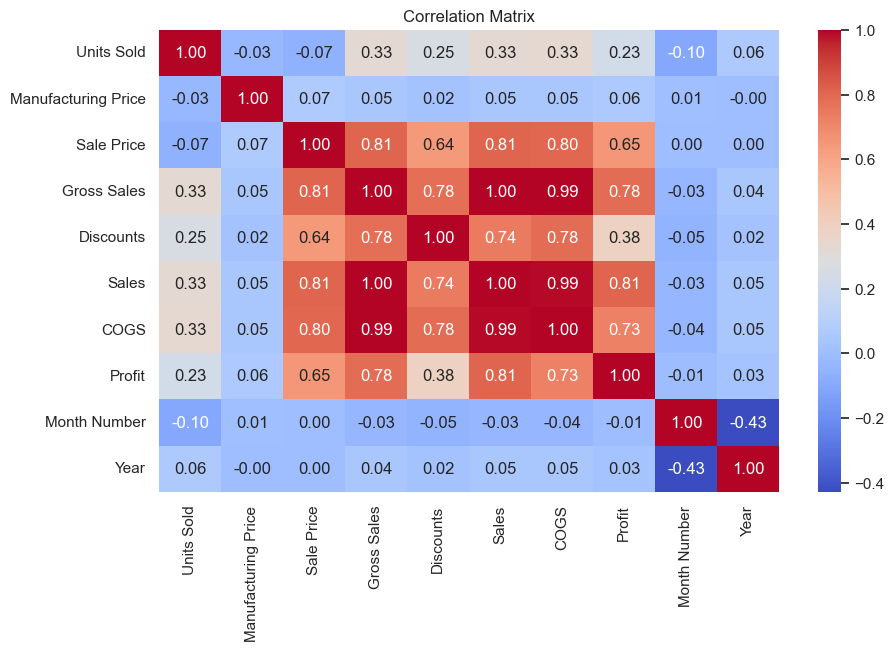

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of Sales
plt.figure(figsize=(8, 4))
sns.histplot(df['Sales'], kde=True)  # Notice 'Sales' is capitalized and clean now!
plt.title('Distribution of Sales')
plt.show()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## Train Regressionn Model

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Select your features and target
# We pick numerical columns that logical impact sales (Units Sold, Manufacturing Price, Sale Price)
X = df[['Units Sold', 'Manufacturing Price', 'Sale Price', 'COGS']]
y = df['Sales']

# 2. Split into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predict on testing data
y_pred = model.predict(X_test)

# 5. Evaluate results
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R²): {r2:.2f}")

--- Model Performance ---
Mean Squared Error (MSE): 990820577.12
R-squared Score (R²): 0.98


In [41]:
import numpy as np

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"R-squared Score (R²): {r2:.2f}")
print(f"Average Model Error (RMSE): ${rmse:.2f}")

R-squared Score (R²): 0.98
Average Model Error (RMSE): $31477.30
